IL MECCANISMO DI ATTENTION: OLTRE I LIMITI DEL COLLO DI BOTTIGLIA

Questo argomento nasce dai limiti di Seq2Seq classico, ed il collo di bottiglia.

I modelli visti finora cercano di comprimere il significato dell'intero testo in un unico piccolo vettore finale.
Oggi diamo alla macchina la capacità di sfogliare il libro, tornare a guardare la pagina che serve nel momento in cui serve.
In questa architettura l'encoder legge tutto e produce un unico vettore fisso perdendo informazioni utili. L'attention scardina questo sistema, non c'è più un imbuto ma una scorciatoria che permette al decodere di accedere ad un qualsiasi stato prodotto dell'encoder durante la lettura.

L'Encoder comprime tutta la frase in una rappresentazione di dimensione fissa, questo è il collo di bottiglia di questa architettura
Tutte la frase -> un solo vettore -> traduzione
finchè la frase è corta, può funzionare abbastanza bene.
Ma immagina frasi molto lunghe l'Encoder dovrebbe riuscire a condensare informazioni tutto nello stesso stato finale.
Più la sequenza diventa lunga, più questa compressione può diventare problematica.
Ed è qui che arriva l'Attention

L'idea:
Invece di obbligare il Decoder a usare soltante l'ultimo stato dell'Encoder, gli permettiamo di accedere a tutti gli satti prodotti dall'Encoder e di scegliere, a ogni passo, quali sono più rilevanti.
Quindi l'Encoder non produce soltanto l'ultimo stato ma una sequenza di stati ad ogni lettura di parola.
Il Decoder ora può consultare tutti gli stati, invece di riceverne solo uno riassuntivo di tutto.
L'Attention è dinamica e viene ricalcolata ad ogni passo del Decoder
Il Decoder può cambiare continualmente dove guarda, da qui il note Attention = attenzione selettiva sulle parti rilevanti dell'input

Quindi l'Encoder non produce soltanto:
ultimo stato
ma una sequenza di stati
The -> h1
black -> h2
cat -> h3
is -> h4
sleeping -> h5
on -> h6
the -> h7
sofa -> h8
h1, ... h8 non sono parole, sono vettori numerici, ognuno contiene una rappresentazione numerica di ciò che l'Encoder ha elaborato fino a quel punto.
Naturalmente la rete non memorizza letteralmente la frase, ma una sua rappresentazione numerica compressa (fino dove è arrivata a leggere) che il modello ha imparato a rendere utili per il task.
Ed è qui che entra in gioco l'Attention, conservi tutti gli stati h1, h2, ... hn e il Decoder può decidere quale usasre maggiormente
Il Decoder può ora consultare tutti gli stati h1, h2, h3, ...
invece di ricevere solo h8

h1, h2, h3… sono le rappresentazioni numeriche prodotte dall’Encoder mentre attraversa i diversi token della sequenza.

Con l'Attention il decoder è come un lettore attivo.
- Accesso agli stati itermedi: il decoder non riceve solo l'ultimo stato dell'encoder ma ha visibilità su ogni singolo step temporale dell'input
- Rilevanza dinamica: per ogi parola da generare, il modello decide quali parole dell'input sono più importanti in quel preciso istante. mentre il decoder sta scrivendo una specifica parola, decide quali parti dell'input sono fondamentali, l'attenzione è on demand..
- Flessibilità delle memoria: le sequenze lunghe non perdono più informazioni iniziali perchè l'attenzione le recupera on-demand.
- Vettore di contesto dinamico: il ponte tra encoder e decoder viene ricalcolato ad ogni passo della generazione.

Ma come fa il decoder a sapere cosa cercare?
L'Intuizione dell'Allineamento
In una traduzione, una parola target non dipende equamente da tutte le perole sorgente. 'Attention' emula il comportamento umano di focalizzarsi su termini specifici.
Invece di sperare che l'ultimo stato contenga tutto, interroghiamo l'intera sequenza di stati nascosti prodotti dall'encoder.
Lo stato corrente del decoder agisce come una 'domanda' (query) posta alla memoria dell'encoder per trovare le informazioni necessarie. e l'encoder risponde mostrando i suoi stati.

Per ogni parola dell'input e dell'output calcoliamo un punteggio di allineamento che misura la loro affinità semantica.
Questo punteggio determina quanto il decoder debba prestare attenzione allo stato h dell'encoder, attirando le informazioni più utili dalla memoria dell'encoder.

Interpretazione e Visualizzazione
Il vero regalo dell'Attention è rendere il Deep Learning meno magico e più spiegabile.
In genere le reti neurali, sono scatole neri imperscrutabili. Con l'Attention possiamo visualizzare cosa sta succendedo, ci mostra dove l'ai ho posto lo sguardo.
Con l'Attention uno dei vantaggi più straordinari è che ci permette di visualizzare ciò che il modello sta effettivamente facendo durante il processo.
Attraverso le mappe di attenzione, possiamo osservare come il modello aliinei parole di lingue diverse, rivelando la logica della traduzione.

L'Attention MAP
Analisi della matrice di allineamento
- Matrice di colore: una griglia dove le righe sono l'output e le colonne l'input, evidenziando le connessioni forti
- Allineamento non lineare: mostra come il modello gestisce le inversioni sintattiche (es. aggettivo-nome in lingue diverse)
- Debug del modello: se la mappa è confusa o sparsa male, indica che il modello non sta apprendendo correttamente le relazioni
- Spiegabilità: fornisce una prova visiva del perchè il modello ha scelto una determinata parola in uscita.

Applicazioni Pratiche della Mappa
La mappa è uno strumento di debug potentissimo. Possiamo verificare se il modello riesce a connettere parole distanti 30 o 40 token, superando i limiti delle RNN classiche.
Se il modello fallisce su frasi lunghe, possiamo guardare la mappa e scoprire se sta fissando parole a caso se il focus svanice.
L'attenzione tende a cadere sui nomi propri o sui verbi d'azione, confermando che il modello assegna pesi corretti ai token informativi.
La mappa rivela come la 'query' del decoder cerchi la 'key' corrispondente nell'encoder, validando l'architettura.

>>> Fase 1: Addestramento della rete...


c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\keras\src\backend\torch\rnn.py:656: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, h_n, c_n = torch._VF.lstm(


>>> Addestramento completato!


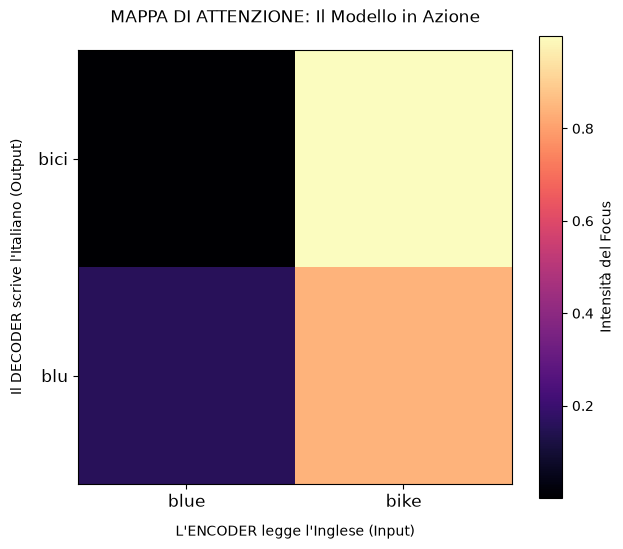

In [1]:
"""
ESEMPIO 58: IL "FOCUS" DELL'INTELLIGENZA ARTIFICIALE (ATTENTION MECHANISM)
--------------------------------------------------------------------------
OBIETTIVO: Tradurre coppie "Colore + Oggetto" dall'Inglese (es. "red car") 
all'Italiano (es. "auto rossa"). 

COSA IMPAREREMO:
1. Come l'Encoder "legge" e crea una memoria.
2. Come il Decoder "scrive" consultando la memoria tramite l'Attention.
3. Come visualizzare il "lampo di genio" (i pesi di attenzione) che permette
   alla rete di capire che l'ordine delle parole va invertito.
"""

# --- PREPARAZIONE AMBIENTE ---
import os
# Spieghiamo a Keras di usare PyTorch come "motore" del calcolo (Best Practice 2026)
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, ops

# =================================================================
# 1. GENERAZIONE DATI: IL NOSTRO MINI-PROBLEMA DI TRADUZIONE
# =================================================================

def genera_dati_didattici(n_esempi=1000):
    """
    Crea un dataset dove l'ordine delle parole cambia tra Input e Output.
    Esempio: Input ["red", "car"] -> Output ["<START>", "auto", "rossa"]
    """
    # Vocabolari semplici
    colori = ['red', 'blue', 'green', 'yellow']
    oggetti = ['car', 'ball', 'bike', 'house']
    colori_it = ['rossa', 'blu', 'verde', 'gialla']
    oggetti_it = ['auto', 'palla', 'bici', 'casa']
    
    # Trasformiamo le parole in numeri (id) per la rete neurale
    voc_in = {p: i+1 for i, p in enumerate(colori + oggetti)}
    voc_out = {p: i+1 for i, p in enumerate(oggetti_it + colori_it)}
    voc_out['<START>'] = len(voc_out) + 1 # Segnale di inizio per il Decoder
    
    x, y = [], []
    for _ in range(n_esempi):
        c_idx, o_idx = np.random.randint(0, 4), np.random.randint(0, 4)
        # Input EN: [Colore, Oggetto]
        x.append([voc_in[colori[c_idx]], voc_in[oggetti[o_idx]]])
        # Output IT: [<START>, Oggetto, Colore] -> Notate l'inversione!
        y.append([voc_out['<START>'], voc_out[oggetti_it[o_idx]], voc_out[colori_it[c_idx]]])
        
    return np.array(x), np.array(y), voc_in, voc_out

# Carichiamo i dati e creiamo dizionari "inversi" per leggere i risultati
X, Y, voc_in, voc_out = genera_dati_didattici()
inv_voc_in = {i: p for p, i in voc_in.items()}
inv_voc_out = {i: p for p, i in voc_out.items()}

# =================================================================
# 2. ARCHITETTURA: IL DIALOGO TRA ENCODER, DECODER E ATTENTION
# =================================================================

def build_attention_model(input_vocab_size, output_vocab_size, embed_dim=32, latent_dim=64):
    """
    COSTRUZIONE DELLA RETE (PIANO DI ARCHITETTURA)
    Spiegazione delle dinamiche parola per parola:
    """
    
    # --- PARTE 1: L'ENCODER (La 'memoria a breve termine' che legge l'inglese) ---
    
    # Input: Porta d'ingresso. shape=(None,) significa: "accetta frasi di qualsiasi lunghezza".
    encoder_inputs = layers.Input(shape=(None,), name="Input_Inglese")
    
    # Embedding: Il 'Traduttore Concettuale'. Trasforma l'ID numerico della parola in un 
    # vettore di 32 numeri (embed_dim) che ne esprime il significato profondo.
    # mask_zero=True permette di ignorare eventuali padding (Best Practice per Seq2Seq).
    encoder_emb = layers.Embedding(input_vocab_size + 1, embed_dim, mask_zero=True)(encoder_inputs)
    
    # LSTM dell'Encoder: Il 'Lettore Attento'. 
    # - latent_dim: 64 'neuroni' che decidono cosa ricordare e cosa dimenticare.
    # - return_sequences=True: DINAMICA FONDAMENTALE. Dice alla LSTM: "Non darmi solo 
    #   il riassunto finale, ma lasciami un appunto per OGNI parola che leggi" (Slide 4).
    # - return_state=True: Chiede alla LSTM di consegnare anche i suoi 'stati interni' 
    #   finali (h e c), che serviranno per dare il 'contesto iniziale' al Decoder.
    encoder_outputs, state_h, state_c = layers.LSTM(
        latent_dim, return_sequences=True, return_state=True
    )(encoder_emb)
    
    # --- PARTE 2: IL DECODER (Lo 'scrittore' che genera l'italiano) ---
    
    # Input del Decoder: Riceve la parola italiana precedente per decidere la successiva.
    decoder_inputs = layers.Input(shape=(None,), name="Input_Italiano_Precedente")
    
    # Embedding del Decoder: Analogo a quello dell'encoder, ma per il vocabolario italiano.
    decoder_emb = layers.Embedding(output_vocab_size + 1, embed_dim, mask_zero=True)(decoder_inputs)
    
    # LSTM del Decoder: 
    # - initial_state=[state_h, state_c]: DINAMICA DI PASSAGGIO CONSEGNE. 
    #   Il Decoder inizia a pensare partendo esattamente da dove l'Encoder ha finito di leggere.
    decoder_lstm = layers.LSTM(latent_dim, return_sequences=True, return_state=True)
    decoder_outputs, _, _ = decoder_lstm(decoder_emb, initial_state=[state_h, state_c])
    
    # --- PARTE 3: MECCANISMO DI ATTENTION (Il 'Faro' o 'Torcia Elettrica') ---
    
    # layers.Attention: La classe che calcola la 'vicinanza' tra concetti (Slide 6).
    attention_layer = layers.Attention(name="Meccanismo_di_Attention")
    
    # Esecuzione Attention:
    # - [decoder_outputs, encoder_outputs]: DINAMICA DI CONFRONTO. 
    #   Mette in relazione "Cosa sto scrivendo ora" (Query) con "Tutto quello che è 
    #   stato letto" (Keys/Values).
    # - return_attention_scores=True: Ci restituisce i famosi 'Pesi Alpha' (Slide 10) 
    #   che useremo per disegnare la mappa colorata.
    context_vector, attention_weights = attention_layer(
        [decoder_outputs, encoder_outputs], 
        return_attention_scores=True
    )
    
    # --- PARTE 4: SINTESI E PREDIZIONE (Il verdetto finale) ---
    
    # Concatenate: DINAMICA DI UNIONE. Incolla insieme lo stato attuale del decoder 
    # con il 'Vettore di Contesto' (il distillato dei ricordi suggerito dall'Attention).
    decoder_combined_context = layers.Concatenate()([decoder_outputs, context_vector])
    
    # Dense con Softmax: DINAMICA DI SCELTA. Guarda il vettore unito e assegna una 
    # probabilità a ogni parola del vocabolario. Quella con il valore più alto 'vince'.
    output_dense = layers.Dense(output_vocab_size + 1, activation="softmax")
    predictions = output_dense(decoder_combined_context)
    
    # --- PARTE 5: CREAZIONE DEI MODELLI (I 'Cervelli' finali) ---
    
    # model: Il modello completo. Prende l'input inglese e quello italiano precedente 
    # per sfornare la predizione. Si usa per l'addestramento.
    model = keras.Model([encoder_inputs, decoder_inputs], predictions)
    
    # attention_visualizer: Modello 'Voyeur'. Invece della traduzione, ci sputa fuori 
    # solo i pesi dell'attenzione. Serve solo a noi umani per 'vedere' l'IA pensare.
    attention_visualizer = keras.Model([encoder_inputs, decoder_inputs], attention_weights)
    
    return model, attention_visualizer

# Creazione e Compilazione
full_model, att_model = build_attention_model(len(voc_in), len(voc_out))
full_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")

# =================================================================
# 3. ALLENAMENTO (TEACHER FORCING)
# =================================================================

print(">>> Fase 1: Addestramento della rete...")
# Y_in: Gli diamo la frase corretta troncata all'ultima parola (per imparare a prevedere la prossima)
# Y_out: La frase corretta che deve riuscire a generare
Y_in, Y_out = Y[:, :-1], Y[:, 1:]
full_model.fit([X, Y_in], Y_out, epochs=40, batch_size=32, verbose=0)
print(">>> Addestramento completato!")

# =================================================================
# 4. VISUALIZZAZIONE: APRIAMO LA SCATOLA NERA (Slide 11-12)
# =================================================================

def mostra_pensiero_ia(index=0):
    """
    Funzione per scattare una 'fotografia' a dove l'IA ha messo l'attenzione.
    """
    input_seq = X[index:index+1]
    target_seq = Y_in[index:index+1]
    
    # Chiediamo al modello di attenzione: "Fammi vedere i tuoi calcoli interni"
    # weights avrà forma (1, parole_out, parole_in)
    weights = att_model.predict([input_seq, target_seq], verbose=0)[0]
    
    # Prepariamo i testi per gli assi del grafico
    testo_in = [inv_voc_in[i] for i in input_seq[0]]
    testo_out = [inv_voc_out[i] for i in Y[index][1:]]
    
    # Disegniamo la mappa di calore (Heatmap)
    plt.figure(figsize=(7, 6))
    plt.imshow(weights, cmap='magma') # Mostriamo tutti i passi (niente più slice errati!)
    
    plt.xticks(range(len(testo_in)), testo_in, fontsize=12)
    plt.yticks(range(len(testo_out)), testo_out, fontsize=12)
    
    plt.title("MAPPA DI ATTENZIONE: Il Modello in Azione", pad=20)
    plt.xlabel("L'ENCODER legge l'Inglese (Input)", labelpad=10)
    plt.ylabel("Il DECODER scrive l'Italiano (Output)", labelpad=10)
    plt.colorbar(label="Intensità del Focus")
    plt.show()

# Eseguiamo la visualizzazione sul primo esempio
mostra_pensiero_ia(0)

# -------------------------------------------------------------------------
# GUIDA RAPIDA ALLA LETTURA DEL CODICE:
# -------------------------------------------------------------------------
# 1. PERCHÉ LSTM (return_sequences=True)?
#    Senza questo, l'Encoder darebbe solo l'ultimo stato (Slide 3: il collo di bottiglia). 
#    Con True, ogni parola ("red", "car") genera un vettore di memoria dedicato.
#
# 2. COS'È IL CONTEXT VECTOR? (Slide 14)
#    È il risultato del livello Attention. Se il modello sta scrivendo "auto", 
#    l'Attention peserà di più (es. 0.95) la memoria di "car" e meno (es. 0.05) quella 
#    di "red". Il Context Vector sarà "quasi uguale" al vettore di "car".
#
# 3. COME LEGGERE IL GRAFICO? (Slide 12)
#    Cerca i quadrati luminosi! Vedrai che quando l'IA scrive "auto" (asse Y), 
#    il quadrato più luminoso sarà in corrispondenza di "car" (asse X). 
#    Questo conferma che l'Attention funziona e ha imparato l'allineamento.